In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Collecting data

In [2]:
df = pd.read_csv("../datasets/PRDECT-ID Dataset.csv")
df.head()

,Category,Product Name,Location,Price,Overall Rating,Number Sold,Total Review,Customer Rating,Customer Review,Sentiment,Emotion
0,Computers and Laptops,Wireless Keyboard i8 Mini TouchPad Mouse 2.4G ...,Jakarta Utara,53500,4.9,5449,2369,5,Alhamdulillah berfungsi dengan baik. Packaging...,Positive,Happy
1,Computers and Laptops,PAKET LISENSI WINDOWS 10 PRO DAN OFFICE 2019 O...,Kota Tangerang Selatan,72000,4.9,2359,1044,5,"barang bagus dan respon cepat, harga bersaing ...",Positive,Happy
2,Computers and Laptops,SSD Midasforce 128 Gb - Tanpa Caddy,Jakarta Barat,213000,5.0,12300,3573,5,"barang bagus, berfungsi dengan baik, seler ram...",Positive,Happy
3,Computers and Laptops,ADAPTOR CHARGER MONITOR LCD LED TV LG merek LG...,Jakarta Timur,55000,4.7,2030,672,5,bagus sesuai harapan penjual nya juga ramah. t...,Positive,Happy
4,Computers and Laptops,ADAPTOR CHARGER MONITOR LCD LED TV LG merek LG...,Jakarta Timur,55000,4.7,2030,672,5,"Barang Bagus, pengemasan Aman, dapat Berfungsi...",Positive,Happy


In [3]:
print(f"Total rows: {len(df)}")
print(f"Total duplicates: {df.duplicated().sum()}")
print("\nMissing values per column:")
print(df.isnull().sum())

Total rows: 5400
Total duplicates: 7

Missing values per column:
Category           0
Product Name       0
Location           0
Price              0
Overall Rating     0
Number Sold        0
Total Review       0
Customer Rating    0
Customer Review    0
Sentiment          0
Emotion            0
dtype: int64


In [4]:
df.drop_duplicates(inplace=True)

# Splitting Dataset

In [5]:
from sklearn.model_selection import train_test_split

In [6]:
strat_train_set, strat_test_set = train_test_split(df, test_size=0.2,
random_state=42, stratify=df["Category"])

# EDA

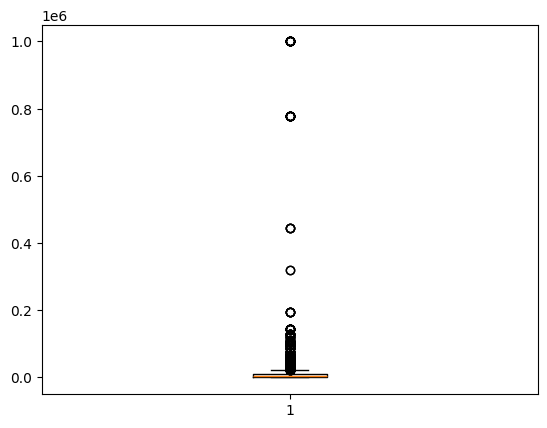

In [7]:
plt.boxplot(strat_train_set["Number Sold"])
plt.show()

In [8]:
threshold_90 = strat_train_set["Number Sold"].quantile(0.9)

In [9]:
count_top_10 = strat_train_set[strat_train_set["Number Sold"] > threshold_90].shape[0]
print(count_top_10)

431


In [10]:
threshold_80 = strat_train_set['Number Sold'].quantile(0.8)
print(threshold_80)

11400.0


In [11]:
count_top_20 = strat_train_set[strat_train_set['Number Sold'] > threshold_80].shape[0]
print(count_top_20)

860


Kuantil 80% dari Number Sold yaitu 11100.0 akan dijadikan threshold penjualan banyak.
Dikarenakan terdapat lebih banyak produk yang melebihi kuantil tersebut, dan dapat dibilang ini adalah kesuksesan umum untuk suatu produk


In [12]:
threshold = threshold_80

# Feature Engineering

In [13]:
def add_top_product_feature(data, threshold):
    df_copy = data.copy()
    df_copy['is_top_product'] = ((df_copy['Overall Rating'] > 4) & (df_copy['Number Sold'] > threshold)).astype(int)
    return df_copy

strat_train_set = add_top_product_feature(strat_train_set, threshold_80)
strat_test_set = add_top_product_feature(strat_test_set, threshold_80)

print(strat_train_set['is_top_product'].value_counts())

is_top_product
0    3454
1     860
Name: count, dtype: int64


# EDA

In [14]:
corr_matrix = strat_train_set.corr(numeric_only=True)
corr_matrix["is_top_product"].sort_values(ascending=False)

is_top_product     1.000000
Total Review       0.570505
Number Sold        0.330803
Overall Rating     0.051963
Price             -0.106602
Customer Rating   -0.155944
Name: is_top_product, dtype: float64

<Axes: xlabel='is_top_product', ylabel='Price'>

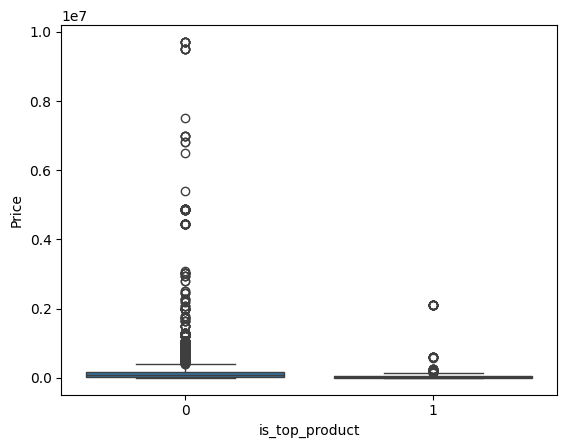

In [15]:
sns.boxplot(data=strat_train_set, x="is_top_product", y="Price")
# plt.boxplot(x=strat_train_set["is_top_product"], y=)
# strat_train_set["is_top_product"].boxplot()

produk yang memiliki atribut is_top_product 1, harganya lebih murah daripada produk yang memiliki atribut is_top_product 0, kesimpulannya adalah semakin kecil Price maka semakin besar jumlah pembelinya. Ini sebagai justifikasi penggunaan kolom price karena pada cell sebelumnya, dapat dilihat bahwa price memiliki korelasi negatif.

<Axes: xlabel='Price', ylabel='is_top_product'>

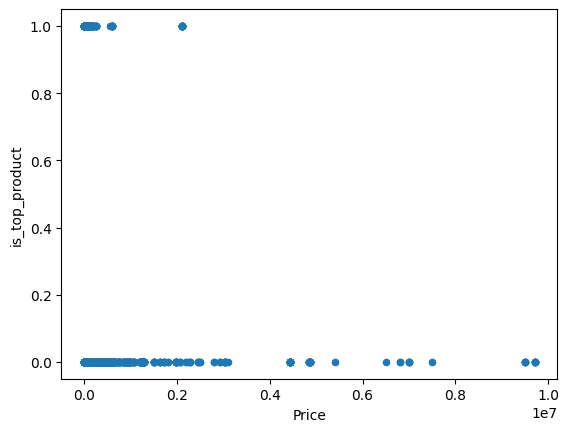

In [16]:
strat_train_set.plot(kind="scatter", x="Price", y="is_top_product")

<Axes: >

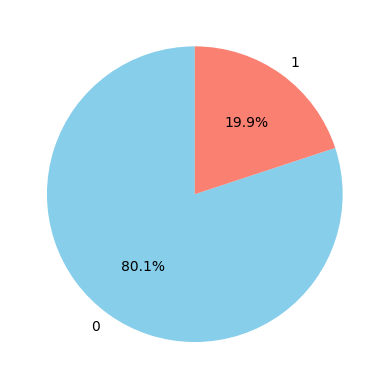

In [17]:
counts = strat_train_set['is_top_product'].value_counts()

# Plot as pie
counts.plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=['skyblue', 'salmon'])

selisih dari rasio nilai target besar, artinya data ini memiliki imbalance

# Data Preprocessing

In [18]:
import copy

In [19]:
df = copy.deepcopy(strat_train_set)
df.head()

,Category,Product Name,Location,Price,Overall Rating,Number Sold,Total Review,Customer Rating,Customer Review,Sentiment,Emotion,is_top_product
1775,Carpentry,Wallpaper Dinding 3D Foam Batu Bata 70cm x 77c...,Jakarta Barat,3700,4.8,112600,3958,1,bahan sangat tipis dan mudah robek karena lem ...,Negative,Fear,1
3847,Household,RB-C158 Kotak Sepatu Lipat Transparan Tebal Sh...,Kota Tangerang,6385,4.7,120294,7211,1,"Barang tidak sesuai dgn yg di gambar, bukan pl...",Negative,Fear,1
5044,Camera,Microphone Boya BY MM1 CardioId Shotgun mic DS...,Jakarta Barat,245000,4.9,4652,2252,3,"Saya melihat review produk ini , hasil suara k...",Negative,Fear,0
57,Computers and Laptops,Mouse Wireless Komic KM-803 - 1200DPI Nano USB...,Jakarta Utara,90000,4.8,4563,1811,1,"Mouse kurang bagus , Pointer nya gerak gerak s...",Negative,Sadness,0
3399,Phones and Tablets,USAMS T22 ADAPTER CHARGER 18W QC3.0 FAST CHARGER,Kota Tangerang,98500,4.9,5529,2824,1,"Satu pcs dipakai 1 jam panas, satu lagi tidak ...",Negative,Sadness,0


In [20]:
df = copy.deepcopy(strat_train_set)
df = df.drop(["Number Sold", "Overall Rating", "Customer Review", "Sentiment",
              "Emotion", "Total Review", "Customer Rating", "Product Name"], axis=1)

df_labels = df["is_top_product"]
df = df.drop("is_top_product", axis=1)

Menghapus kolom yang memiliki korelasi rendah, dan kolom-kolom yang tidak berhubungan dengan input untuk model inference nanti, seperti produk baru tidak mungkin memiliki customer rating dan jumlah penjualan.

In [21]:
df.head()

,Category,Location,Price
1775,Carpentry,Jakarta Barat,3700
3847,Household,Kota Tangerang,6385
5044,Camera,Jakarta Barat,245000
57,Computers and Laptops,Jakarta Utara,90000
3399,Phones and Tablets,Kota Tangerang,98500


In [22]:
strat_test_set = strat_test_set.drop(["Number Sold", "Overall Rating", "Customer Review", "Sentiment",
              "Emotion", "Total Review", "Customer Rating", "Product Name"], axis=1)


In [23]:
strat_test_set.head()

,Category,Location,Price,is_top_product
1301,Body Care,Kota Tangerang Selatan,250000,1
1240,Body Care,Kota Tangerang,128600,0
5338,Household,Jakarta Timur,44900,0
4678,Movies and Music,Jakarta Barat,10000,0
2151,Sport,Jakarta Barat,16200,0


In [24]:
from sklearn.preprocessing import OrdinalEncoder
from imblearn.over_sampling import SMOTENC

In [25]:
from sklearn.compose import ColumnTransformer
preprocessor = ColumnTransformer([
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), ["Category", "Location"])
], remainder="passthrough", verbose_feature_names_out=False)

preprocessor.set_output(transform="pandas")


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{fea

# Training

In [26]:
df_labels.head()

1775    1
3847    1
5044    0
57      0
3399    0
Name: is_top_product, dtype: int64

In [27]:
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline as ImbPipeline


In [28]:
full_pipeline = ImbPipeline([
    ("preprocessing", preprocessor),
    ("smotenc", SMOTENC(categorical_features=[0, 1], random_state=42)),
    ("random_forest", RandomForestClassifier(random_state=42))
])


In [29]:
clf = full_pipeline.fit(df, df_labels)

In [30]:
pred = clf.predict(df)
print(pred[:5])
print()
print(df_labels[:5])

[1 1 0 0 0]

1775    1
3847    1
5044    0
57      0
3399    0
Name: is_top_product, dtype: int64


In [31]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(df_labels, pred)
print("Confusion Matrix:\n", cm)

report = classification_report(df_labels, pred, target_names=['Unfit', 'Fit'])
print("\nClassification Report:\n", report)

Confusion Matrix:
 [[3438   16]
 [   3  857]]

Classification Report:
               precision    recall  f1-score   support

       Unfit       1.00      1.00      1.00      3454
         Fit       0.98      1.00      0.99       860

    accuracy                           1.00      4314
   macro avg       0.99      1.00      0.99      4314
weighted avg       1.00      1.00      1.00      4314



# Fine Tuning

In [32]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
from sklearn.pipeline import Pipeline

In [33]:

param_dist = {
    'random_forest__max_features': randint(low=1, high=10),
}

rnd_search = RandomizedSearchCV(
    full_pipeline,
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring='neg_root_mean_squared_error',
    random_state=42
)

rnd_search.fit(df, df_labels)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.",{'random_forest__max_features': <scipy.stats....001D0087E0D70>}
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if

In [34]:
final_model = rnd_search.best_estimator_

In [35]:
pred = final_model.predict(df)
print(pred[:5])
print()
print(df_labels[:5])

[1 1 0 0 0]

1775    1
3847    1
5044    0
57      0
3399    0
Name: is_top_product, dtype: int64


In [36]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(df_labels, pred)
print("Confusion Matrix:\n", cm)

report = classification_report(df_labels, pred, target_names=['Unfit', 'Fit'])
print("\nClassification Report:\n", report)

Confusion Matrix:
 [[3438   16]
 [   3  857]]

Classification Report:
               precision    recall  f1-score   support

       Unfit       1.00      1.00      1.00      3454
         Fit       0.98      1.00      0.99       860

    accuracy                           1.00      4314
   macro avg       0.99      1.00      0.99      4314
weighted avg       1.00      1.00      1.00      4314



# Evaluate

In [37]:
strat_test_set.head()

,Category,Location,Price,is_top_product
1301,Body Care,Kota Tangerang Selatan,250000,1
1240,Body Care,Kota Tangerang,128600,0
5338,Household,Jakarta Timur,44900,0
4678,Movies and Music,Jakarta Barat,10000,0
2151,Sport,Jakarta Barat,16200,0


In [38]:
X_test = strat_test_set.drop("is_top_product", axis=1)
y_test = copy.copy(strat_test_set.iloc[:, -1])

In [39]:
X_test.head()


,Category,Location,Price
1301,Body Care,Kota Tangerang Selatan,250000
1240,Body Care,Kota Tangerang,128600
5338,Household,Jakarta Timur,44900
4678,Movies and Music,Jakarta Barat,10000
2151,Sport,Jakarta Barat,16200


In [40]:
y_test.head()

1301    1
1240    0
5338    0
4678    0
2151    0
Name: is_top_product, dtype: int64

In [41]:
pred = final_model.predict(X_test)

In [42]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, pred)
print("Confusion Matrix:\n", cm)

report = classification_report(y_test, pred, target_names=['Unfit', 'Fit'])
print("\nClassification Report:\n", report)

Confusion Matrix:
 [[872  11]
 [  4 192]]

Classification Report:
               precision    recall  f1-score   support

       Unfit       1.00      0.99      0.99       883
         Fit       0.95      0.98      0.96       196

    accuracy                           0.99      1079
   macro avg       0.97      0.98      0.98      1079
weighted avg       0.99      0.99      0.99      1079



# Save Model

In [43]:
import joblib

joblib.dump(final_model, "e-commerce_analysis_classification_model.pkl")

['e-commerce_analysis_classification_model.pkl']